Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting video processing...
Processing other_crash → 50 videos
Processing rollover → 50 videos
Processing fire_or_explosions → 28 videos
Processing rear_collision → 50 videos
Processing drifting_or_skidding → 50 videos
Processing objects_falling → 39 videos
Processing pedestrian_hit → 11 videos
Processing collision_with_stationary_object → 50 videos
Processing negative_samples → 50 videos
Processing side_collision → 50 videos
Processing collision_with_motorcycle → 50 videos
Processing head_on_collision → 50 videos

Total trajectories: 4747
Normal (0): 878 | Incident (1): 3869


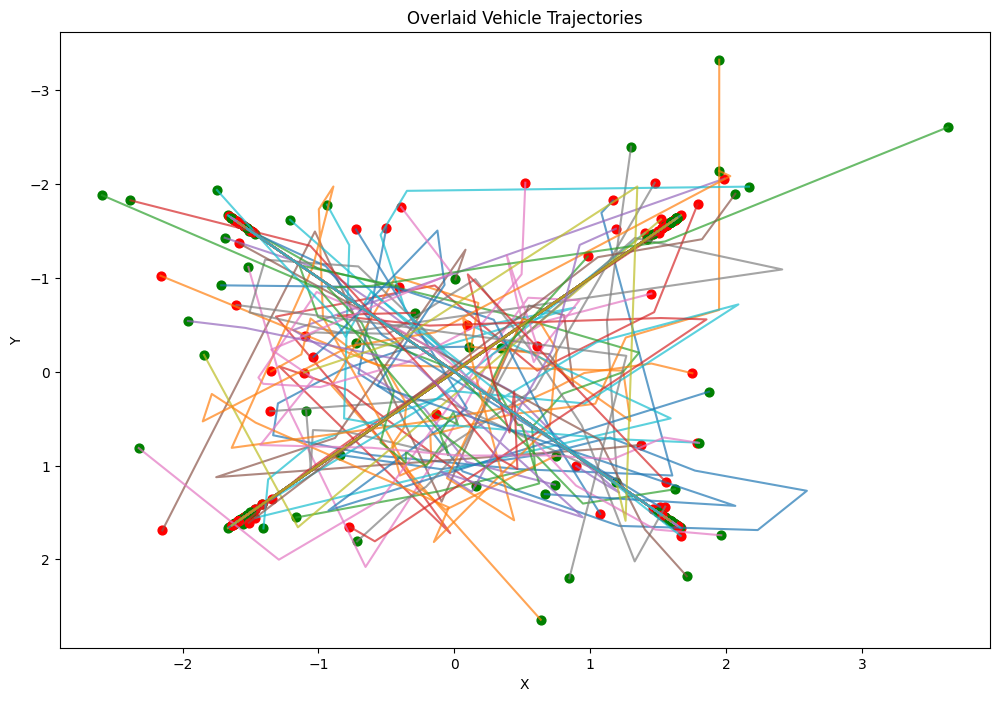

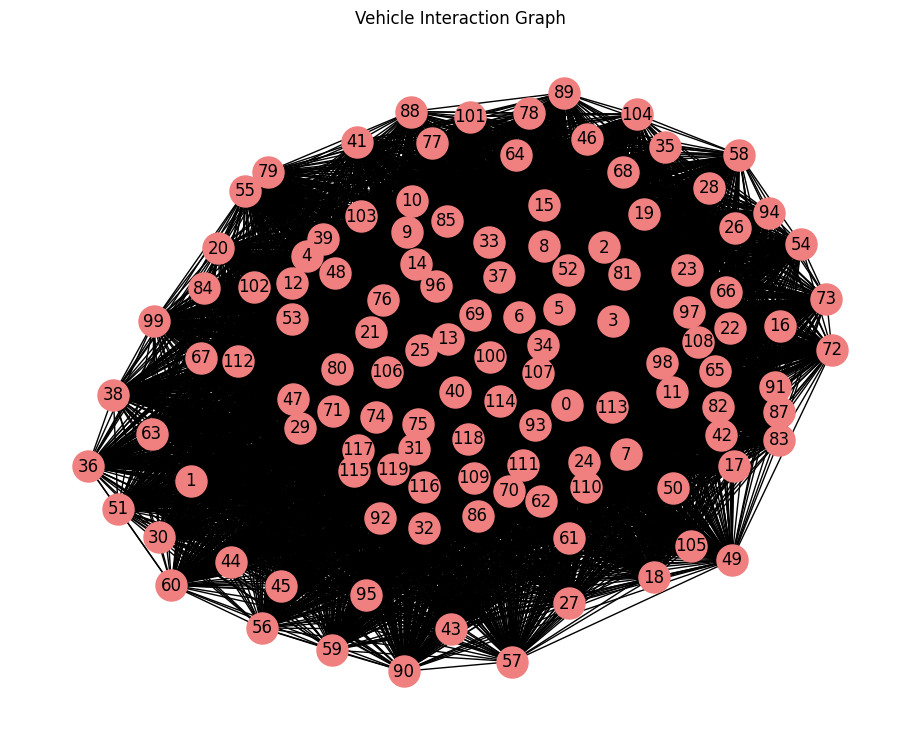

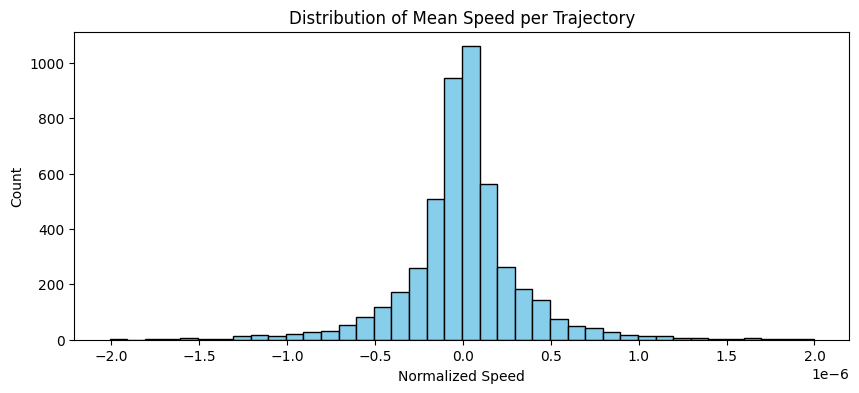

Epoch 1/60 - Loss: 0.5723
Epoch 2/60 - Loss: 0.5642
Epoch 3/60 - Loss: 0.5512
Epoch 4/60 - Loss: 0.5252
Epoch 5/60 - Loss: 0.5617
Epoch 6/60 - Loss: 0.5246
Epoch 7/60 - Loss: 0.5220
Epoch 8/60 - Loss: 0.4983
Epoch 9/60 - Loss: 0.4975
Epoch 10/60 - Loss: 0.4904
Epoch 11/60 - Loss: 0.4770
Epoch 12/60 - Loss: 0.4493
Epoch 13/60 - Loss: 0.4500
Epoch 14/60 - Loss: 0.4422
Epoch 15/60 - Loss: 0.4323
Epoch 16/60 - Loss: 0.4551
Epoch 17/60 - Loss: 0.4212
Epoch 18/60 - Loss: 0.4210
Epoch 19/60 - Loss: 0.4210
Epoch 20/60 - Loss: 0.4050
Epoch 21/60 - Loss: 0.4112
Epoch 22/60 - Loss: 0.3971
Epoch 23/60 - Loss: 0.3977
Epoch 24/60 - Loss: 0.3905
Epoch 25/60 - Loss: 0.3814
Epoch 26/60 - Loss: 0.3790
Epoch 27/60 - Loss: 0.3931
Epoch 28/60 - Loss: 0.3737
Epoch 29/60 - Loss: 0.3923
Epoch 30/60 - Loss: 0.3721
Epoch 31/60 - Loss: 0.3959
Epoch 32/60 - Loss: 0.3711
Epoch 33/60 - Loss: 0.3835
Epoch 34/60 - Loss: 0.3850
Epoch 35/60 - Loss: 0.3686
Epoch 36/60 - Loss: 0.3652
Epoch 37/60 - Loss: 0.3522
Epoch 38/6

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



FINAL RESULTS
              precision    recall  f1-score   support

      Normal     0.4248    0.5455    0.4776       176
    Incident     0.8895    0.8320    0.8598       774

    accuracy                         0.7789       950
   macro avg     0.6571    0.6887    0.6687       950
weighted avg     0.8034    0.7789    0.7890       950

Accuracy: 0.7789473684210526


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch import nn
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from collections import Counter
import networkx as nx


DATA_DIR = "/kaggle/input/hwid12-highway-incidents-detection-dataset/Video-Accident-Dataset"
MAX_VIDEOS_PER_CLASS = 50
SKIP_FRAMES = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# Frame Extraction
# -------------------------------
def extract_frames(video_path, skip=SKIP_FRAMES):
    cap = cv2.VideoCapture(video_path)
    frames = []
    fid = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if fid % skip == 0:
            frames.append(frame)
        fid += 1
    cap.release()
    return frames

# -------------------------------
# YOLO + DeepSORT
# -------------------------------
yolo_model = YOLO("yolov8n.pt")
tracker = DeepSort(max_age=30, embedder_gpu=True)

def detect_vehicles(frames):
    detections = []
    for frame in frames:
        results = yolo_model(frame, verbose=False)[0]
        dets = []
        if results.boxes is not None:
            for box, conf, cls in zip(results.boxes.xyxy, results.boxes.conf, results.boxes.cls):
                c = int(cls)
                if c in [2, 3, 5, 7] and conf > 0.4:
                    dets.append([box.cpu().numpy().tolist(), float(conf), c])
        detections.append(dets)
    return detections

def track_vehicles(frames, detections):
    trajectories = {}
    for t, (frame, dets) in enumerate(zip(frames, detections)):
        if not dets: continue
        tracks = tracker.update_tracks(dets, frame=frame)
        for tr in tracks:
            if not tr.is_confirmed(): continue
            tid = tr.track_id
            if tid not in trajectories:
                trajectories[tid] = []
            x1, y1, x2, y2 = tr.to_tlbr()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            trajectories[tid].append([t, cx, cy])
    return trajectories

# -------------------------------
# Kinematics + Normalization
# -------------------------------
def compute_kinematics(trajectories):
    feats = {}
    for tid, pts in trajectories.items():
        pts = np.array(pts, dtype=np.float32)
        if len(pts) < 5: continue
        pos = pts[:, 1:]  # (T, 2)
        vel = np.diff(pos, axis=0, prepend=pos[:1])
        speed = np.linalg.norm(vel, axis=1, keepdims=True)
        accel = np.diff(speed, axis=0, prepend=speed[:1])

        # Stack + normalize per trajectory (very important!)
        seq = np.hstack([pos, speed, accel])  # (T, 4)
        seq = (seq - seq.mean(axis=0)) / (seq.std(axis=0) + 1e-8)

        feats[tid] = {"seq": seq}
    return feats

# -------------------------------
# Fixed Positional Encoding
# -------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# -------------------------------
# Transformer with masking
# -------------------------------
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, nhead=8, num_layers=3):
        super().__init__()
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.pos_enc = PositionalEncoding(hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=512,
            batch_first=True, dropout=0.1, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.transformer(x, src_key_padding_mask=~mask)  

        if mask is not None:
            mask = mask.unsqueeze(-1).float()  # (B, T, 1)
            x = (x * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  
        else:
            x = x.mean(dim=1)
        return self.fc(x)

# -------------------------------
# Dataset
# -------------------------------
class TrajectoryDataset(Dataset):
    def __init__(self, traj_list, labels):
        self.seqs = [t["seq"] for t in traj_list]
        self.labels = torch.tensor(labels, dtype=torch.long)

        self.max_len = max(len(s) for s in self.seqs)
        self.padded = [np.pad(s, ((0, self.max_len - len(s)), (0, 0)), 'constant') for s in self.seqs]
        self.padded = torch.tensor(np.array(self.padded), dtype=torch.float32)

    def __len__(self):
        return len(self.padded)

    def __getitem__(self, idx):
        seq = self.padded[idx]
        actual_len = len(self.seqs[idx])
        mask = torch.zeros(self.max_len, dtype=torch.bool)
        mask[:actual_len] = True 
        return seq, self.labels[idx], mask

# -------------------------------
# Training with Gradient Clipping
# -------------------------------
def train_model(train_ds, val_ds, epochs=60):
    # Oversample minority class
    weights = [2.0 if l == 0 else 1.0 for l in train_ds.labels]
    sampler = WeightedRandomSampler(weights, len(weights))

    train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    model = TransformerClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor([2.5, 1.0]).to(DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y, mask in train_loader:
            x, y, mask = x.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x, mask)
            loss = criterion(logits, y)
            loss.backward()

            # Critical: prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y, mask in val_loader:
            x, y, mask = x.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
            logits = model(x, mask)
            pred = logits.argmax(1)
            preds.extend(pred.cpu().tolist())
            trues.extend(y.cpu().tolist())

    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    print(classification_report(trues, preds, target_names=["Normal", "Incident"], digits=4))
    print("Accuracy:", accuracy_score(trues, preds))
    return model

# -------------------------------
# Subteam B Visualizations
# -------------------------------
def plot_overlaid_paths(trajs_dict):
    plt.figure(figsize=(12, 8))
    for f in trajs_dict.values():
        seq = f["seq"]
        pos = seq[:, :2]
        plt.plot(pos[:, 0], pos[:, 1], alpha=0.7)
        plt.scatter(pos[0, 0], pos[0, 1], c='green', s=40)
        plt.scatter(pos[-1, 0], pos[-1, 1], c='red', s=40)
    plt.gca().invert_yaxis()
    plt.title("Overlaid Vehicle Trajectories")
    plt.xlabel("X"); plt.ylabel("Y")
    plt.show()

def plot_interaction_diagram(trajs_dict):
    G = nx.Graph()
    ids = list(trajs_dict.keys())
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            p1 = trajs_dict[ids[i]]["seq"][:, :2]
            p2 = trajs_dict[ids[j]]["seq"][:, :2]
            min_dist = np.min(np.linalg.norm(p1[:, None] - p2[None, :], axis=2))
            if min_dist < 0.5:  # normalized distance
                G.add_edge(ids[i], ids[j], weight=round(min_dist, 2))
    plt.figure(figsize=(9, 7))
    nx.draw(G, with_labels=True, node_color='lightcoral', node_size=500)
    plt.title("Vehicle Interaction Graph")
    plt.show()

def plot_speed_histogram(trajs_dict):
    speeds = [np.mean(f["seq"][:, 2]) for f in trajs_dict.values()]
    plt.figure(figsize=(10, 4))
    plt.hist(speeds, bins=40, color='skyblue', edgecolor='black')
    plt.title("Distribution of Mean Speed per Trajectory")
    plt.xlabel("Normalized Speed"); plt.ylabel("Count")
    plt.show()

# -------------------------------
# MAIN: Process 50 videos per class
# -------------------------------
all_features = []
all_labels = []
all_trajs = {}
global_id = 0

print("Starting video processing...")
for cat in os.listdir(DATA_DIR):
    cat_path = os.path.join(DATA_DIR, cat)
    if not os.path.isdir(cat_path): continue

    label = 0 if cat == "negative_samples" else 1
    videos = os.listdir(cat_path)[:MAX_VIDEOS_PER_CLASS]
    print(f"Processing {cat} → {len(videos)} videos")

    for vid_file in videos:
        path = os.path.join(cat_path, vid_file)
        frames = extract_frames(path)
        if len(frames) < 10: continue

        dets = detect_vehicles(frames)
        tracks = track_vehicles(frames, dets)
        feats = compute_kinematics(tracks)

        for tid, f in feats.items():
            all_trajs[global_id] = f
            all_features.append(f)
            all_labels.append(label)
            global_id += 1

print(f"\nTotal trajectories: {len(all_features)}")
print(f"Normal (0): {all_labels.count(0)} | Incident (1): {all_labels.count(1)}")

# Visualizations
sample_trajs = dict(list(all_trajs.items())[:120])
plot_overlaid_paths(sample_trajs)
plot_interaction_diagram(sample_trajs)
plot_speed_histogram(all_trajs)

# Train-test split
train_feats, val_feats, train_y, val_y = train_test_split(
    all_features, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

train_ds = TrajectoryDataset(train_feats, train_y)
val_ds = TrajectoryDataset(val_feats, val_y)

# TRAIN
model = train_model(train_ds, val_ds, epochs=60)


STARTING MODEL TESTING
TESTING MODEL ON SAMPLE VIDEOS

Testing 3 videos from negative_samples (True label: 0)
--------------------------------------------------
Processing: negative_samples_975.mp4
  negative_samples_975.mp4:
    → Trajectories: 12
    → Predictions: {0: 7, 1: 5}
    → Final: 0 (Normal)
    → Confidence: 0.841 - ✓ CORRECT
Processing: negative_samples_978.mp4
  negative_samples_978.mp4:
    → Trajectories: 8
    → Predictions: {0: 4, 1: 4}
    → Final: 0 (Normal)
    → Confidence: 0.881 - ✓ CORRECT
Processing: negative_samples_51.mp4
  negative_samples_51.mp4:
    → Trajectories: 15
    → Predictions: {0: 13, 1: 2}
    → Final: 0 (Normal)
    → Confidence: 0.946 - ✓ CORRECT
Category positive_samples not found, skipping...

PERFORMANCE ANALYSIS
Overall Accuracy: 1.000 (3/3)
Normal Videos: 3 | Correct: 3 | Accuracy: 1.000
Incident Videos: 0 | Correct: 0 | Accuracy: 0.000
Avg Confidence (Correct): 0.889

SAMPLE PREDICTIONS
1. negative_samples_975.mp4
   True: Normal | Pre

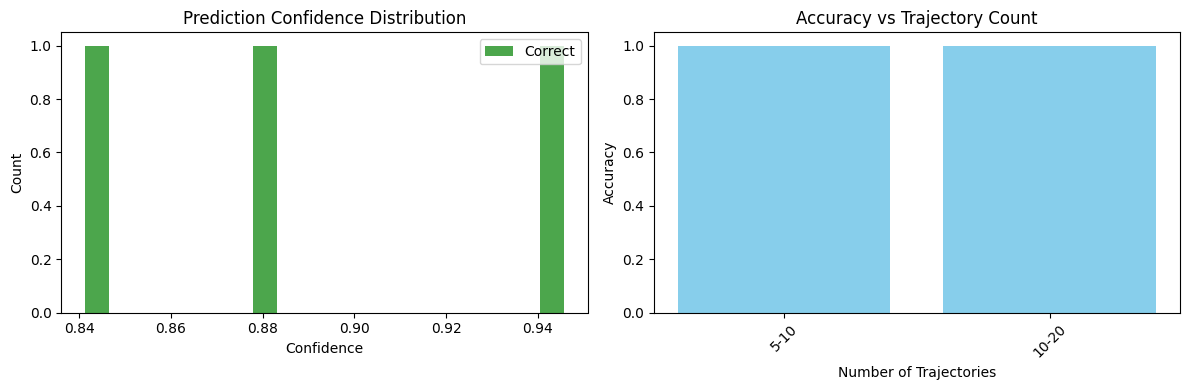


EXTENDED TESTING (5 more samples each)
TESTING MODEL ON SAMPLE VIDEOS

Testing 5 videos from negative_samples (True label: 0)
--------------------------------------------------
Processing: negative_samples_975.mp4
  negative_samples_975.mp4:
    → Trajectories: 16
    → Predictions: {0: 10, 1: 6}
    → Final: 0 (Normal)
    → Confidence: 0.870 - ✓ CORRECT
Processing: negative_samples_978.mp4
  negative_samples_978.mp4:
    → Trajectories: 8
    → Predictions: {0: 4, 1: 4}
    → Final: 0 (Normal)
    → Confidence: 0.881 - ✓ CORRECT
Processing: negative_samples_51.mp4
  negative_samples_51.mp4:
    → Trajectories: 15
    → Predictions: {0: 13, 1: 2}
    → Final: 0 (Normal)
    → Confidence: 0.946 - ✓ CORRECT
Processing: negative_samples_606.mp4
  negative_samples_606.mp4:
    → Trajectories: 19
    → Predictions: {0: 14, 1: 5}
    → Final: 0 (Normal)
    → Confidence: 0.924 - ✓ CORRECT
Processing: negative_samples_191.mp4
  negative_samples_191.mp4:
    → Trajectories: 15
    → Predicti

In [ ]:
# -------------------------------
# TESTING: Make Predictions on Sample Videos
# -------------------------------

def predict_video(video_path, model, yolo_model, tracker, device=DEVICE):
    """
    Make predictions on a single video
    """
    print(f"Processing: {os.path.basename(video_path)}")
    
    # Extract frames
    frames = extract_frames(video_path, skip=SKIP_FRAMES)
    if len(frames) < 5:
        print("  → Too short, skipping")
        return None
    
    # Detect and track vehicles
    detections = detect_vehicles(frames)
    trajectories = track_vehicles(frames, detections)
    features = compute_kinematics(trajectories)
    
    if not features:
        print("  → No vehicles detected")
        return None
    
    # Prepare data for model
    predictions = []
    confidences = []
    traj_ids = []
    
    for tid, feat in features.items():
        seq = feat["seq"]
        if len(seq) < 5:
            continue
            
        # Pad sequence
        max_len = 100  # Use a fixed max length for consistency
        padded_seq = np.pad(seq, ((0, max_len - len(seq)), (0, 0)), 'constant')
        mask = torch.zeros(max_len, dtype=torch.bool)
        mask[:len(seq)] = True
        
        # Convert to tensor
        seq_tensor = torch.tensor(padded_seq, dtype=torch.float32).unsqueeze(0).to(device)
        mask_tensor = mask.unsqueeze(0).to(device)
        
        # Predict
        model.eval()
        with torch.no_grad():
            logits = model(seq_tensor, mask_tensor)
            probs = torch.softmax(logits, dim=1)
            pred = logits.argmax(1).item()
            confidence = probs[0, pred].item()
        
        predictions.append(pred)
        confidences.append(confidence)
        traj_ids.append(tid)
    
    return {
        'video': os.path.basename(video_path),
        'trajectories': len(features),
        'predictions': predictions,
        'confidences': confidences,
        'traj_ids': traj_ids,
        'features': features
    }

def test_model_on_samples(model, num_samples=5):
    """
    Test the model on sample videos from both classes
    """
    print("=" * 70)
    print("TESTING MODEL ON SAMPLE VIDEOS")
    print("=" * 70)
    
    results = []
    
    for category in ['negative_samples', 'positive_samples']:
        cat_path = os.path.join(DATA_DIR, category)
        if not os.path.exists(cat_path):
            print(f"Category {category} not found, skipping...")
            continue
            
        videos = os.listdir(cat_path)[:num_samples]
        true_label = 0 if category == 'negative_samples' else 1
        
        print(f"\nTesting {len(videos)} videos from {category} (True label: {true_label})")
        print("-" * 50)
        
        for video_file in videos:
            video_path = os.path.join(cat_path, video_file)
            result = predict_video(video_path, model, yolo_model, tracker)
            
            if result is not None:
                # Determine overall video prediction (majority vote)
                if result['predictions']:
                    pred_counts = Counter(result['predictions'])
                    majority_pred = pred_counts.most_common(1)[0][0]
                    avg_confidence = np.mean(result['confidences'])
                    
                    result['true_label'] = true_label
                    result['video_prediction'] = majority_pred
                    result['avg_confidence'] = avg_confidence
                    result['correct'] = (majority_pred == true_label)
                    
                    results.append(result)
                    
                    # Print results
                    status = "✓ CORRECT" if result['correct'] else "✗ WRONG"
                    print(f"  {video_file}:")
                    print(f"    → Trajectories: {result['trajectories']}")
                    print(f"    → Predictions: {dict(pred_counts)}")
                    print(f"    → Final: {majority_pred} ({'Incident' if majority_pred == 1 else 'Normal'})")
                    print(f"    → Confidence: {avg_confidence:.3f} - {status}")
                else:
                    print(f"  {video_file}: No valid predictions")
            else:
                print(f"  {video_file}: Failed to process")
    
    return results

def analyze_test_results(results):
    """
    Analyze and display test results
    """
    if not results:
        print("No results to analyze!")
        return
    
    print("\n" + "=" * 70)
    print("PERFORMANCE ANALYSIS")
    print("=" * 70)
    
    # Calculate metrics
    correct_predictions = sum(1 for r in results if r['correct'])
    total_videos = len(results)
    accuracy = correct_predictions / total_videos if total_videos > 0 else 0
    
    # Per-class analysis
    normal_videos = [r for r in results if r['true_label'] == 0]
    incident_videos = [r for r in results if r['true_label'] == 1]
    
    normal_correct = sum(1 for r in normal_videos if r['correct'])
    incident_correct = sum(1 for r in incident_videos if r['correct'])
    
    print(f"Overall Accuracy: {accuracy:.3f} ({correct_predictions}/{total_videos})")
    print(f"Normal Videos: {len(normal_videos)} | Correct: {normal_correct} | Accuracy: {normal_correct/len(normal_videos) if normal_videos else 0:.3f}")
    print(f"Incident Videos: {len(incident_videos)} | Correct: {incident_correct} | Accuracy: {incident_correct/len(incident_videos) if incident_videos else 0:.3f}")
    
    # Confidence analysis
    correct_confidences = [r['avg_confidence'] for r in results if r['correct']]
    wrong_confidences = [r['avg_confidence'] for r in results if not r['correct']]
    
    if correct_confidences:
        print(f"Avg Confidence (Correct): {np.mean(correct_confidences):.3f}")
    if wrong_confidences:
        print(f"Avg Confidence (Wrong): {np.mean(wrong_confidences):.3f}")
    
    # Show some examples
    print("\n" + "=" * 70)
    print("SAMPLE PREDICTIONS")
    print("=" * 70)
    
    for i, result in enumerate(results[:8]):  # Show first 8 results
        true_label_str = "Normal" if result['true_label'] == 0 else "Incident"
        pred_str = "Normal" if result['video_prediction'] == 0 else "Incident"
        
        print(f"{i+1}. {result['video']}")
        print(f"   True: {true_label_str} | Pred: {pred_str} | Conf: {result['avg_confidence']:.3f}")
        print(f"   Trajectories: {result['trajectories']} | Correct: {result['correct']}")
        print()

# -------------------------------
# VISUALIZE TEST RESULTS
# -------------------------------

def visualize_test_predictions(results, sample_trajs):
    """
    Create visualizations for test predictions
    """
    if not results:
        return
    
    # Plot confidence distribution
    plt.figure(figsize=(12, 4))
    
    # Confidence by correctness
    plt.subplot(1, 2, 1)
    correct_conf = [r['avg_confidence'] for r in results if r['correct']]
    wrong_conf = [r['avg_confidence'] for r in results if not r['correct']]
    
    if correct_conf:
        plt.hist(correct_conf, alpha=0.7, label='Correct', bins=20, color='green')
    if wrong_conf:
        plt.hist(wrong_conf, alpha=0.7, label='Wrong', bins=20, color='red')
    
    plt.xlabel('Confidence')
    plt.ylabel('Count')
    plt.title('Prediction Confidence Distribution')
    plt.legend()
    
    # Accuracy by number of trajectories
    plt.subplot(1, 2, 2)
    traj_counts = [r['trajectories'] for r in results]
    correct = [r['correct'] for r in results]
    
    # Bin by trajectory count
    bins = [0, 1, 3, 5, 10, 20, 50]
    bin_accuracy = []
    bin_labels = []
    
    for i in range(len(bins)-1):
        mask = (np.array(traj_counts) >= bins[i]) & (np.array(traj_counts) < bins[i+1])
        if mask.any():
            acc = np.mean(np.array(correct)[mask])
            bin_accuracy.append(acc)
            bin_labels.append(f"{bins[i]}-{bins[i+1]}")
    
    plt.bar(bin_labels, bin_accuracy, color='skyblue')
    plt.xlabel('Number of Trajectories')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Trajectory Count')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()



# Test the trained model on sample videos
print("\n" + "=" * 70)
print("STARTING MODEL TESTING")
print("=" * 70)

test_results = test_model_on_samples(model, num_samples=3)

# Analyze results
analyze_test_results(test_results)

# Visualize results
visualize_test_predictions(test_results, sample_trajs)

print("\n" + "=" * 70)
print("EXTENDED TESTING (5 more samples each)")
print("=" * 70)

extended_results = test_model_on_samples(model, num_samples=5)
final_results = test_results + extended_results

print("\n" + "=" * 70)
print("FINAL EXTENDED ANALYSIS")
print("=" * 70)
analyze_test_results(final_results)

In [12]:
import os
import torch
from datetime import datetime

# Create a folder for models
os.makedirs("/kaggle/working/saved_models", exist_ok=True)

# Save the full model (recommended for easy loading later)
model_save_path = "/kaggle/working/saved_models/accident_detection_transformer.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': ['Normal', 'Incident'],
    'input_features': 4,
    'hidden_dim': 128
}, model_save_path)

print(f"Model successfully saved to:")
print(f"   {model_save_path}")


Model successfully saved to:
   /kaggle/working/saved_models/accident_detection_transformer.pth
